# Import libraries

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import numpy as np
import glob

In [23]:
files = glob.glob("../csv_files/time_data/*/*.csv")

# Define stabilization point function

In [44]:

def interpolate_nans(signal):
    return pd.Series(signal).interpolate(method='linear', limit_direction='both').to_numpy()

def find_std_stabilization_point(signal, window_size=50, std_thresh=0.01):
    for i in range(len(signal) - window_size):
        window = signal[i:i+window_size]
        if np.std(window) < std_thresh:
            return i  # index where it starts to stabilize
    return None  # never stabilizes

def find_mean_threshold_stabilization_point(signal, window_size=20, epsilon=0.01, min_stable_duration=50):
    signal = np.asarray(signal)
    N = len(signal)

    # Compute moving mean over window
    moving_means = np.convolve(signal, np.ones(window_size)/window_size, mode='valid')

    # Loop through moving averages to find a stretch that stays within epsilon
    for start in range(len(moving_means) - min_stable_duration):
        window = moving_means[start:start + min_stable_duration]
        if np.max(window) - np.min(window) < epsilon:
            return start + window_size - 1  # Adjust index to original signal

    return None  # No stabilization point found

70
None
500


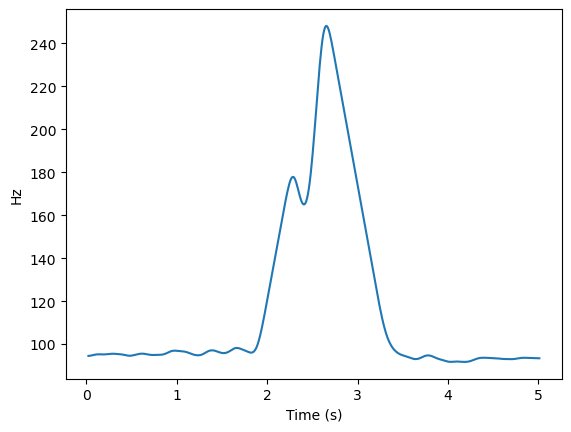

In [45]:
df = pd.read_csv(files[3])



noisy_signal = interpolate_nans(df["F0"].values)

# Example: smoothing a noisy signal
smoothed = gaussian_filter1d(noisy_signal, sigma=5)

plt.plot(df["time"], smoothed)
plt.xlabel("Time (s)")
plt.ylabel("Hz")

print(find_std_stabilization_point(smoothed, window_size=5, std_thresh=0.01))
print(find_mean_threshold_stabilization_point(smoothed, window_size=20, epsilon=0.01, min_stable_duration=30))
print(len(smoothed))
